In [2]:
import pandas as pd
import sqlite3
import datetime
from os import path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:

#--------Directories ---------------------------------------
## Project directory
project_dir = path.dirname(path.dirname(path.abspath('')))

## Location of database files
db_dir = path.join(project_dir,"files", "data", "lfs", "UWB")

## Location for Graphs
graph_dir = path.join(project_dir, "files", "data", "lfs","UWB",  "graphs")

metadata_dir = path.join(project_dir, "files", "data", "lfs","UWB", "metadata")

In [4]:
def generate_lineplot(df, select_date_start=None, select_date_end=None, component=None,
                      scope=None, save_fig=True, graphs_dir=graph_dir,
                      stations_meta=None, components_meta=None):

    # --- Date range ---
    start = select_date_start if select_date_start else str(df['date_start'].iloc[0])
    end   = select_date_end   if select_date_end   else str(df['date_start'].iloc[-1])

    df_plt = df.query(f'date_start >= "{start}" and date_start < "{end}"').copy()

    # --- Metadata lookups ---
    # Component info
    comp_name, comp_symbol, comp_unit = "Unknown", "", ""
    if components_meta is not None and component is not None:
        row = components_meta[components_meta['component_id'] == component]
        if not row.empty:
            comp_name   = row['component_name'].values[0]
            comp_symbol = row['component_symbol'].values[0]
            comp_unit   = row['component_unit'].values[0]

    # Station label map: station_id → "CODE – Name"
    label_map = {}
    if stations_meta is not None:
        for sid in df_plt['station_id'].unique():
            row = stations_meta[stations_meta['station_id'] == sid]
            if not row.empty:
                code = row['station_code'].values[0]
                name = row['station_name'].values[0]
                label_map[sid] = f"{code} – {name}"
            else:
                label_map[sid] = str(sid)

    df_plt['station_label'] = df_plt['station_id'].map(label_map).fillna(df_plt['station_id'].astype(str))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(40, 10))

    sns.lineplot(data=df_plt, x="date_start", y="value",
                 hue="station_label", ax=ax, linewidth=1.2)

    # Title
    date_range_str = f"{start[:10]}  →  {end[:10]}"
    ax.set_title(
        f"{comp_name} ({comp_symbol})  |  {date_range_str}",
        fontsize=18, fontweight='bold', pad=16
    )

    # Axis labels
    ax.set_xlabel("Datum", fontsize=13)
    ax.set_ylabel(f"{comp_symbol}  [{comp_unit}]", fontsize=13)

    # Legend
    ax.legend(
        title="Messstation",
        title_fontsize=12,
        fontsize=11,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0,
        frameon=True
    )

    ax.xaxis.set_major_formatter(
        plt.matplotlib.dates.DateFormatter('%Y-%m-%d')
    )
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

    # --- Save ---
    if save_fig:
        plt_name = f'UWB_{comp_symbol}_{start[:10]}--{end[:10]}.pdf'
        file_path = path.join(graphs_dir, plt_name)
        fig.savefig(file_path, bbox_inches='tight')

    plt.show()

In [5]:
def filter_db_files(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db"
    ) -> list:
    if station_id == None:
        station_id ="*"

    if component == None:
        component = "*"

    if scope == None:
        scope = "*"

    mask = f'station_{station_id}*_comp_{component}*_scope_{scope}*{file_type}'
    files = glob.glob(path.join(db_dir, mask))
    files_filterd = []
    for file in files:
        if path.getsize(file) >= min_filesize:
            files_filterd.append(file)
    return files_filterd

In [6]:
def load_dbs(
        station_id: int | None = None,
        component: int | None = None,
        scope: int | None = None,
        min_filesize: int = 20000,
        file_type: str = "db",
        project_dir: str = 'files/data/lfs/UWB'
    ) -> list:
    dfs = []
    files = filter_db_files(station_id, component, scope, min_filesize, file_type)
    for file in files:
        conn = sqlite3.connect(file)
        df = pd.read_sql_query("SELECT * FROM measurements", conn)
        dfs.append(df)
    df = pd.concat(dfs,ignore_index=True)

    # 1. Identify which rows have the 24:00:00 problem
    mask = df["date_end"].str.contains("24:00:00")

    # 2. Replace 24:00:00 with 00:00:00 so pandas can parse it
    df["date_end"] = df["date_end"].str.replace("24:00:00", "00:00:00")

    # 3. Convert to datetime
    df["date_end"] = pd.to_datetime(df["date_end"])

    # 4. Add exactly 1 day to the rows that originally had 24:00:00
    df.loc[mask, "date_end"] += pd.Timedelta(days=1)
    df["date_start"] = pd.to_datetime(df["date_start"])
    df["date_end"] = pd.to_datetime(df["date_end"])
    df["station_id"] = df["station_id"].astype(str)
    df = df.drop("index_value", axis=1)

    return df

In [55]:
## Load the Measurement data
df = load_dbs("*", component=1, scope=2, project_dir=db_dir)

In [8]:
## Load the metadata
stations_meta    = pd.read_csv(path.join(metadata_dir,"UWB_stations_metadata.csv"))
stations_meta['station_id'] = stations_meta['station_id'].astype(str)
components_meta  = pd.read_csv(path.join(metadata_dir,"UWB_components_metadata.csv"))

In [9]:
components_meta.head()

,component_id,component_code,component_symbol,component_unit,component_name
0,1,PM10,PM₁₀,µg/m³,Feinstaub
1,2,CO,CO,mg/m³,Kohlenmonoxid
2,3,O3,O₃,µg/m³,Ozon
3,4,SO2,SO₂,µg/m³,Schwefeldioxid
4,5,NO2,NO₂,µg/m³,Stickstoffdioxid


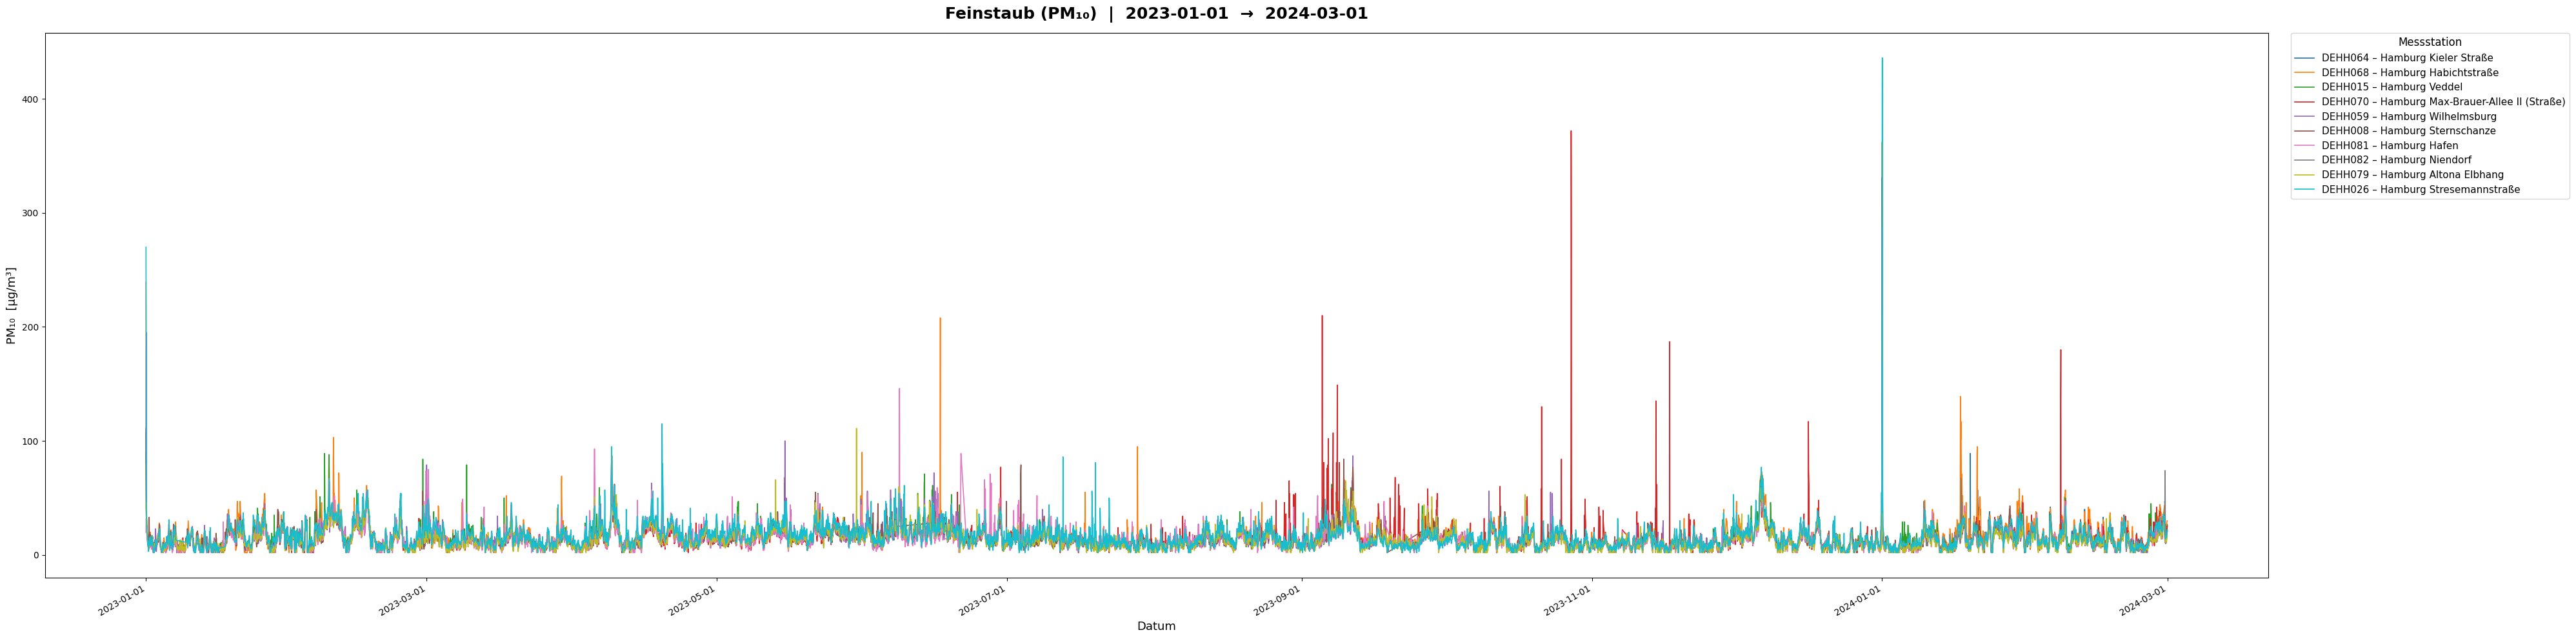

In [10]:

generate_lineplot(
    df,
    select_date_start="2023-01-01",
    select_date_end="2024-03-01",
    component=1,                      # 1 = PM10 / Feinstaub
    stations_meta=stations_meta,
    components_meta=components_meta,
)

In [11]:
df.head()

,date_start,date_end,station_id,component_id,scope_id,value
0,2024-01-01 00:00:00,2024-01-01 01:00:00,840,1,2,157.0
1,2024-01-01 01:00:00,2024-01-01 02:00:00,840,1,2,122.0
2,2024-01-01 02:00:00,2024-01-01 03:00:00,840,1,2,43.0
3,2024-01-01 03:00:00,2024-01-01 04:00:00,840,1,2,18.0
4,2024-01-01 04:00:00,2024-01-01 05:00:00,840,1,2,18.0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 596112 entries, 0 to 596111
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_start    596112 non-null  datetime64[us]
 1   date_end      596112 non-null  datetime64[us]
 2   station_id    596112 non-null  str           
 3   component_id  596112 non-null  int64         
 4   scope_id      596112 non-null  int64         
 5   value         581529 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(1)
memory usage: 27.3 MB


In [45]:
# Filter for stations in Hamburg
stations_meta_ham = stations_meta[stations_meta["network_name"]=="Hamburg"]
stations_meta_ham.set_index('station_id',inplace=True)

In [49]:
stations_meta_ham.loc['857']

station_code                        DEHH081
station_name                  Hamburg Hafen
station_city                        Hamburg
station_synonym                         NaN
station_active_from              2015-09-29
station_active_to                       NaN
station_longitude                    9.9816
station_latitude                    53.5292
network_id                                6
station_setting_id                        1
station_type_id                           1
network_code                             HH
network_name                        Hamburg
station_setting_name             urban area
station_setting_short_name            urban
station_type_name                background
station_street                    Worthdamm
station_street_nr                        49
station_zip_code                      20457
Name: 857, dtype: object

In [30]:
components  = [1, 2, 3, 4, 5]

In [56]:
frames = []
for component in components:
    df = load_dbs('*', component=str(component), scope='*')
    frames.append(df)


In [59]:
frames

[                 date_start            date_end station_id  component_id  \
 0       2024-01-01 00:00:00 2024-01-01 01:00:00        840             1   
 1       2024-01-01 01:00:00 2024-01-01 02:00:00        840             1   
 2       2024-01-01 02:00:00 2024-01-01 03:00:00        840             1   
 3       2024-01-01 03:00:00 2024-01-01 04:00:00        840             1   
 4       2024-01-01 04:00:00 2024-01-01 05:00:00        840             1   
 ...                     ...                 ...        ...           ...   
 1192219 2025-12-31 19:00:00 2025-12-31 20:00:00        855             1   
 1192220 2025-12-31 20:00:00 2025-12-31 21:00:00        855             1   
 1192221 2025-12-31 21:00:00 2025-12-31 22:00:00        855             1   
 1192222 2025-12-31 22:00:00 2025-12-31 23:00:00        855             1   
 1192223 2025-12-31 23:00:00 2026-01-01 00:00:00        855             1   
 
          scope_id  value  
 0               6    NaN  
 1               6